In [1]:
%load_ext autoreload
%autoreload 2

import os,sys
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import util as yu
from util import *
import util_Nsgm as yu2

yu.setpath('check_lbdfit')

In [2]:
path='/capstor/store/cscs/userlab/lp139/lyan/code/projectData/01_Nsgm/data/Nsgm_4src_16,18,20_cB211.072.64.h5'
# yu.print_hdf5_structure(path)

opabs=['g;0,0,0;G1g;a;l1;N_g;0,0,0;G1g;a;l1;N', 'g;0,0,0;G1g;a;l2;N_g;0,0,0;G1g;a;l2;N']
with h5py.File(path) as f:
    dic=yu.list2dic(yu.decodeList(f['diags/N/opabs'][:]))
    t=f['diags/N/data/p_p'][:]
    t=np.mean([t[:,:,dic[opab]] for opab in opabs],axis=0)
    t=np.real(t)
    c2pt=yu.jackknife(t)
    
ens='b'
mul=yu.ens2amul[ens]

tfs=[8,10,12,14,16,18,20]

tf2c3pt_conn={}
tf2c3pt_disc={}
opabs=['g;0,0,0;G1g;a;l1;N_g;0,0,0;G1g;a;l1;N', 'g;0,0,0;G1g;a;l2;N_g;0,0,0;G1g;a;l2;N']
path='/capstor/store/cscs/userlab/lp139/lyan/code/projectData/01_Nsgm/data/Nsgm_4src_16,18,20_cB211.072.64.h5'
with h5py.File(path) as f:
    cfgs=yu.decodeList(f['cfgs'])
    for tf in tfs:
        iins=yu.decodeList(f['diags/NJN/inserts']).index('id')
        dic=yu.list2dic(yu.decodeList(f['diags/NJN/opabs'][:]))
        t=f[f'diags/NJN/data/p_j+_p_deltat_{tf}'][:,:,:,iins]
        t=np.mean([t[:,:,dic[opab]] for opab in opabs],axis=0)
        t=np.real(t*mul)
        t=yu.jackknife(t)
        tf2c3pt_conn[tf]=t

        iins=yu.decodeList(f['diags/N-j/inserts']).index('id')
        dic=yu.list2dic(yu.decodeList(f['diags/N-j/opabs'][:]))
        t=f[f'diags/N-j/data/p_j+_p_deltat_{tf}'][:,:,:,iins]
        t=np.mean([t[:,:,dic[opab]] for opab in opabs],axis=0)
        t=np.real(t*mul)
        t=yu.jackknife(t)
        
        tvev=np.real(f['VEV/j/data/j+'][:,iins]*mul)
        tvev=yu.jackknife(tvev)
        
        tf2c3pt_disc[tf]=t-c2pt[:,tf:tf+1]*tvev[:,None]

cfg2old=lambda cfg: cfg[1:]+'_r'+{'a':'0','b':'1','c':'2','d':'3'}[cfg[0]]
cfg2new=lambda cfg: {'0':'a','1':'b','2':'c','3':'d'}[cfg[-1]] + cfg[:4]
path='/capstor/store/cscs/userlab/lp139/lyan/code/projectData_old/01_Nsgm/cB211.072.64_base/data_from_others/thrp-conn.h5'
with h5py.File(path) as f:
    cfgs_old=[cfg2old(cfg) for cfg in cfgs]

    tf2c3pt_conn_more={tf:np.real(yu.jackknife([f[f'gS/up/dt{tf}/{cfg}'][:] + f[f'gS/dn/dt{tf}/{cfg}'][:] for cfg in cfgs_old])*mul) for tf in tfs}
    tf2c2pt={tf:np.real(yu.jackknife([f[f'dt{tf}_twop/{cfg}'][()] for cfg in cfgs_old])) for tf in tfs}
    
tf2c3pt={}
for tf in tfs:
    tf2c3pt[tf]=tf2c3pt_conn_more[tf]+tf2c3pt_disc[tf]
    if True:
        tf2c3pt[tf]=(tf2c3pt[tf]+tf2c3pt[tf][:,::-1])/2

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/capstor/store/cscs/userlab/lp139/lyan/code/projectData/01_Nsgm/data/Nsgm_4src_16,18,20_cB211.072.64.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

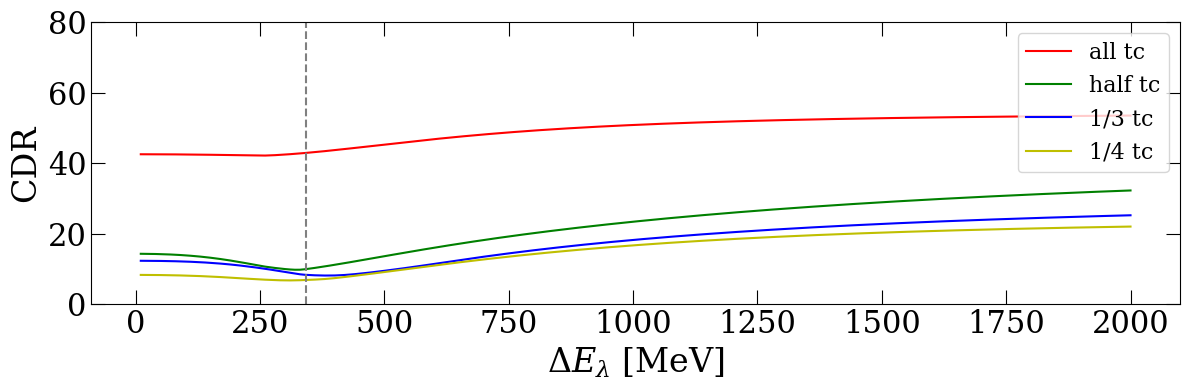

In [ ]:
n=2
def dE2lbd(dE):
    lbd0=dE*n
    return np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)

def lbd2tf2ratio(dE):    
    lbd=dE2lbd(dE)
    tf2ratio={}
    for tf in tfs:
        c3=tf2c3pt[tf]
        c3=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd**2*c3
        c2=(lbd**2)*c2pt[:,tf]
        tf2ratio[tf]=c3/c2[:,None]*yu.ens2aInv[ens]
    return tf2ratio

def getCDR(dE,downsampling=1):
    tf2ratio=lbd2tf2ratio(dE)
    
    tfmin=8; tcmin=3
    tfs=[tf for tf in tf2ratio.keys() if tf>=tfmin ]
    tf2tcs={tf:np.arange(tcmin,tf//2+1,downsampling) for tf in tfs}
    
    y=np.concatenate([tf2ratio[tf][:,tf2tcs[tf]] for tf in tfs],axis=1)
    cov=yu.jackmec(y)[-1]
    cdr=yu.getCDR(cov)
    
    return cdr

dEs=np.arange(10,2000+1,10)

fig,axs=yu.getFigAxs(1,1,Lrow=4,Lcol=12)
ax=axs[0,0]

cdrs=[getCDR(dE/yu.ens2aInv[ens]) for dE in dEs]
ax.plot(dEs,cdrs,'r-',label='all tc')

cdrs=[getCDR(dE/yu.ens2aInv[ens],downsampling=2) for dE in dEs]
ax.plot(dEs,cdrs,'g-',label='half tc')

cdrs=[getCDR(dE/yu.ens2aInv[ens],downsampling=3) for dE in dEs]
ax.plot(dEs,cdrs,'b-',label='1/3 tc')

cdrs=[getCDR(dE/yu.ens2aInv[ens],downsampling=4) for dE in dEs]
ax.plot(dEs,cdrs,'y-',label='1/4 tc')

ax.legend()
ax.set_xlabel(r'$\Delta E_{\lambda}$ [MeV]')
ax.set_ylabel('CDR (dB)')
ax.set_ylim([0,80])

yu.addRefLine(ax,342.9564513796705,hv='v')
yu.finalizePlot()

In [4]:
yu.setpath('analysis_noNsgm')
[pars_jk_meff1st,pars_jk_meff2st,pars_jk_meff3st]=yu.load_pkl_reg('pars_jk_meffnst')
yu.setpath('check_lbdfit')

In [5]:
n=2
fitlabel_chosen=(8,4)
def dE2lbd(dE):
    lbd0=dE*n
    return np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)

def lbd2tf2ratio(dE):    
    lbd=dE2lbd(dE)
    
    tf2ratio={}
    for tf in tfs:
        c3=tf2c3pt[tf]
        c3=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd**2*c3
        c2=(lbd**2)*c2pt[:,tf]
        tf2ratio[tf]=c3/c2[:,None]*yu.ens2aInv[ens]
    return tf2ratio
tfmins=[8,10,12,14,16,18]
tcmins=range(n+1,8+1)
fits_laplace=yu.doFits_3pt_lbd(lbd2tf2ratio,tfmins,tcmins,symmetrizeQ=True,label='lbd_test',verbose=2)
fits_laplace=[[(tfmin,tcmin),np.array([pars_jk[:,0],np.abs(pars_jk[:,1])]).T,chi2_jk,Ndof] for (tfmin,tcmin),pars_jk,chi2_jk,Ndof in fits_laplace]
fit_MA_laplace=yu.doMA_3pt(fits_laplace,fitlabels=fitlabel_chosen)
# tf2ratio={}
# for tf in tfs:
#     tf2ratio[tf]=tf2c3pt[tf]/c2pt[:,tf:tf+1]*yu.ens2aInv[ens]
# dic={
#     'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,None,fits,None,None],
#     'fit_const:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,None,None,None,None],
#     'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
#     'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,1,None],
#     'xyunit':[yu.ens2a[ens],1],
#     # 'fit_2st_rainbow_midpoint:[fittype,pars_jk_meff2st]':['2st2step_SYMshare',pars_jk_meff2st],
#     'mfc:[global]':['None'],
# }
# fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','fit_const'])
# axs[0,0].set_ylim([5,100])
# yu.finalizePlot()

# fits


In [6]:
tf2ratio={}
for tf in tfs:
    tf2ratio[tf]=tf2c3pt[tf]/c2pt[:,tf:tf+1]

overwrite=False

tfmins_2st=[8,10,12,14,16,18]
tcmins_2st=[1,2,3,4,5,6,7,8]
fits_2st=yu.doFits_3pt('2st2step_SYMshare',tf2ratio,tfmins_2st,tcmins_2st,pars_jk_meff2st=pars_jk_meff2st,symmetrizeQ=True,label=f'2st')
fits_sum=yu.doFits_3pt('sum',tf2ratio,tfmins_2st[:5],[n+1],label=f'sum',overwrite=overwrite)

dic={
    'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,None,None,fits_sum,fits_2st],
    'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
    'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,1,None],
    'xyunit':[yu.ens2a[ens],yu.ens2aInv[ens]],
    # 'fit_2st_rainbow_midpoint:[fittype,pars_jk_meff2st]':['2st2step_SYMshare',pars_jk_meff2st],
    'mfc:[global]':['None'],
}

dE=np.mean(fit_MA_laplace[0][:,1])
print(dE*yu.ens2aInv[ens])
tf2ratio_laplace=lbd2tf2ratio(dE)
tfmins=[8,10,12,14,16,18]
tcmins=range(n+1,8+1)
fits_const_2=yu.doFits_3pt('const',tf2ratio_laplace,tfmins,tcmins,symmetrizeQ=True,label=f'const_2_laplace')
fit_const_MA_2=yu.doMA_3pt(fits_const_2,fitlabels=fitlabel_chosen)
dic2={
    'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio_laplace,None,fits_laplace,None,None],
    'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,fit_MA_laplace,None,None],
    'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,n+1,None],
    'xyunit':[yu.ens2a[ens],1],
    'mfc:[global]':['white'],
} 

dic3={
    'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio_laplace,None,fits_const_2,None,None],
    'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,fit_const_MA_2,None,None],
    'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,n+1,None],
    'xyunit':[yu.ens2a[ens],1],
    'mfc:[global]':['white'],
} 

342.9564513796705


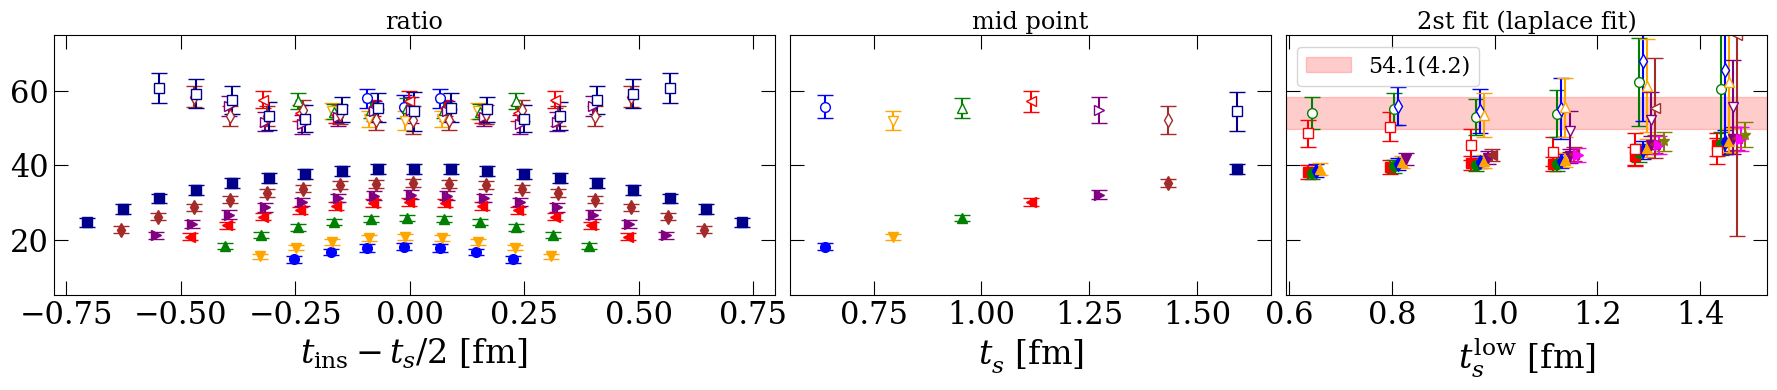

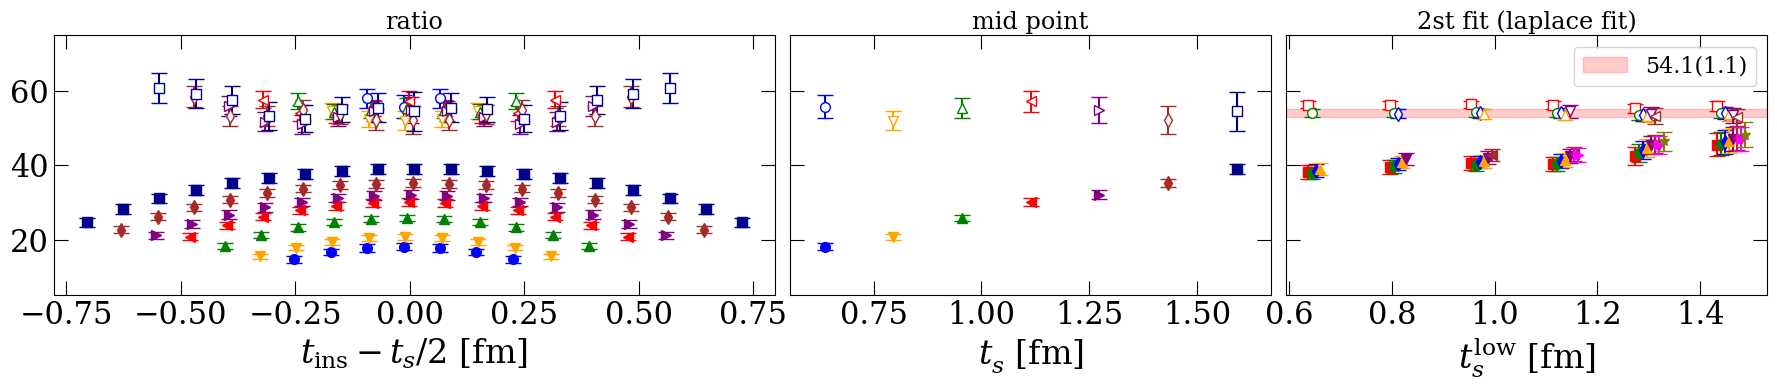

In [7]:
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint','fit_2st'],colHeaders=None)
axs[0,0].set_ylim([5,75])
yu.addColHeader(axs,['ratio','mid point','2st fit (laplace fit)'])
fig,axs=yu.makePlot_3pt(dic2,shows=['rainbow','midpoint','fit_const'],figAxs=(fig,axs),colHeaders=None)
yu.finalizePlot('lbdfit',closeQ=False)

fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint','fit_2st'],colHeaders=None)
axs[0,0].set_ylim([5,75])
yu.addColHeader(axs,['ratio','mid point','2st fit (laplace fit)'])
fig,axs=yu.makePlot_3pt(dic3,shows=['rainbow','midpoint','fit_const'],figAxs=(fig,axs),colHeaders=None)
yu.finalizePlot('fit2lbdfit',closeQ=False)